# ***Comparing the Black Scholes-Model to Other Numerical Methods***

**1.0: Project:**
- To predict American Options Pricings using algorithms over a given period of time by comparing the Black-Scholes Method (adjusted for American Options) to other Numerical estimation methods.

**1.1: Definitions:**
1. **Option:** a security giving the right to buy/sell an asset within a specified period of time
2.  **Call:** an option that gives the holder the right to BUY the underlying asset at a strike price at some moment in the future
3. **Put:** an option that gives the holder the right to SELL the underlying asset at a strike price at some moment in the future
4. **Expiration Date:** The date on which an option right or warrant expires, & becomes worthless if not exercised. \
(i) **European Option:** An option that CANNOT be exercised until the expiration date. \
(ii) **American Option:** An option that can be exercised at any time up to & including the expiration date.
5. **Risk-Free Interest Rate:** The annual interest rate of "risk-free" investments.
6. **Volatility:** The measure for variation in price for a financial instrument. \
(i) **Implied Volatility:** volatility derived from the market price of a market-traded derivative.
7. **Strike Price:** The predetermined price of an underlying asset.



**1.2: Definition of Black-Scholes Model:**
- It is constructing a "riskless" portfolio taking positions in bonds, options and the underlying stock.
- The equation predicts the price of the option over time
- The fundamental formula is primarily used to obtain the price of option calls.

We will use the formulas as defined below:


$C_{\text{call}} = S \phi(d_1) - X e^{-rT} \phi(d_2) \tag{7}$

$P_{\text{put}} = X e^{-rT} \phi(-d_2) - S \phi(-d_1) \tag{8}$



where
$d_1 = \frac{\log(S / X) + (r + \sigma^2 / 2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}$, and:

$C_{\text{call}}$ – the price for an option call \
$P_{\text{put}}$ – the price for an option put \
$S$ – the current option price of the stock \
$X$ – the strike price of an underlying stock \
$r$ – the annualized risk-free interest rate, continuously compounded \
$T$ – the time in year until the expiration of the option \
$\sigma$ – implied volatility of an underlying stock \
$\Phi(.)$ – the standard normal cumulative distribution function.

Here, $\phi(d)$ denotes the standard normal cumulative distribution function and it is defined as follows:

$\phi(d) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d} e^{-x^2 / 2} dx \tag{9}$

**1.3: Assumptions:**

1. "risk-free" interest rate to be kept constant.
2. Stock follows a "random walk" in cont. time; variance of the stock price paths = log-normal distr.
3. Volatility to be kept constant.
4. Stock = pays no dividends (can be adjusted for)
5. EUROPEAN type option
6. No transaction costs (usually ~$0.04 / contract)
7. Fractional Trading is possible; we can buy ~0.x of any given stock, x = integer.


In [1]:
#Import dependencies
import yfinance as yf
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.stats import norm

# **Analytical Method (Black-Scholes; European):**

In order to check the accuracy of the other numerical methods, we will first start by calculating the Call and Put option values using the analytical formula\.



In [2]:
#Probability Density function; phi(d)
N = norm.cdf

#Define Call Option
def BlackSchole_Call(S, X, T, r, sigma):
    d1 = (np.log(S/X) + (r + (pow(sigma, 2) / 2)) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))

    return S*N(d1) - X*np.exp(-r*T)*N(d2)

#Define Put Option
def BlackSchole_Put(S, X, T, r, sigma):
    d1 = (np.log(S/X) + (r + (pow(sigma, 2) / 2)) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    return X*np.exp(-r*T)*N(-d2) - S*N(-d1)

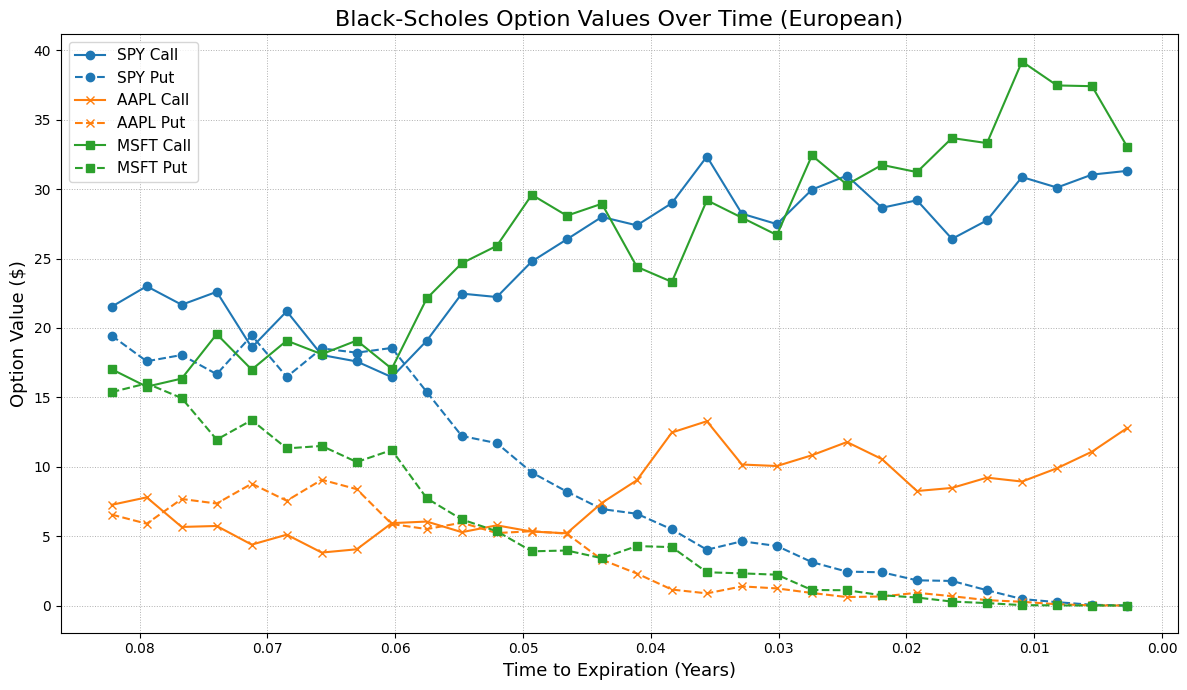

In [3]:
#Analytical Method

#Parameters
r = 0.0425 #risk-free interest rate; as of 05/01/2025
sigma = 0.30 #Constant Implied volatility
days = 30 #No. of historical Days to analyze
T_total = days / 365 #Total time to expiration (in years)

stockList = ['SPY', 'AAPL', 'MSFT'] #List of stocks chosen

#Plot setup
plt.figure(figsize=(12,7))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
markers = ['o', 'x', 's', '^', 'd']

#Fetching data
for idx, stock_symbol in enumerate(stockList):
    stock = yf.Ticker(stock_symbol)
    hist = stock.history(period=f'{days+5}d')
    closing_prices = list(hist['Close'][-days:])

    #Throw errors
    if len(closing_prices) < days:
      print(f"Warning: Not enough data for {stock_symbol}. Skipping.")
      continue

    """
    Set At-The-Money (ATM) strike price at FIRST day
    In this case, our strike price would be determined by our interval
    """
    strike = closing_prices[0]

    #Calculating Black-Scholes Values
    call_values = []
    put_values = []
    T_values = []

    for i, prices in enumerate(closing_prices):
      T = T_total - (i/365) #Days to exp decreases each day.
      if T <= 0:
        continue
      call_values.append(BlackSchole_Call(prices, strike, T, r, sigma))
      put_values.append(BlackSchole_Put(prices, strike, T, r, sigma))
      T_values.append(T)

    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]

    plt.plot(T_values, call_values, marker=marker, color=color, label=f'{stock_symbol} Call')
    plt.plot(T_values, put_values, marker=marker, color=color, linestyle='--', label=f'{stock_symbol} Put')

#Plot touchups
plt.gca().invert_xaxis()  # Time to expiration decreasing left to right
plt.title('Black-Scholes Option Values Over Time (European)', fontsize=16)
plt.xlabel('Time to Expiration (Years)', fontsize=13)
plt.ylabel('Option Value ($)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()


# **Numerical Method #1: Binomial Tree**

In order to test out the accuracy of the Black-Scholes Equation, we will estimate the Options prices using some numerical methods. Since we are focusing on American Options, we will first take a look at the Binomial Tree Method.


The Model assumes that stock prices will move either up or down. Based on this, the model will iteratively generate different paths of stock price evolution.

Why Binomial Tree:
- We are able to exercise the option at any given time; i.e. we can choose a node from the tree at a given time point, rather than only see the value at the expiration date (Like European Black-Scholes).

We will use the following equations to define the model:


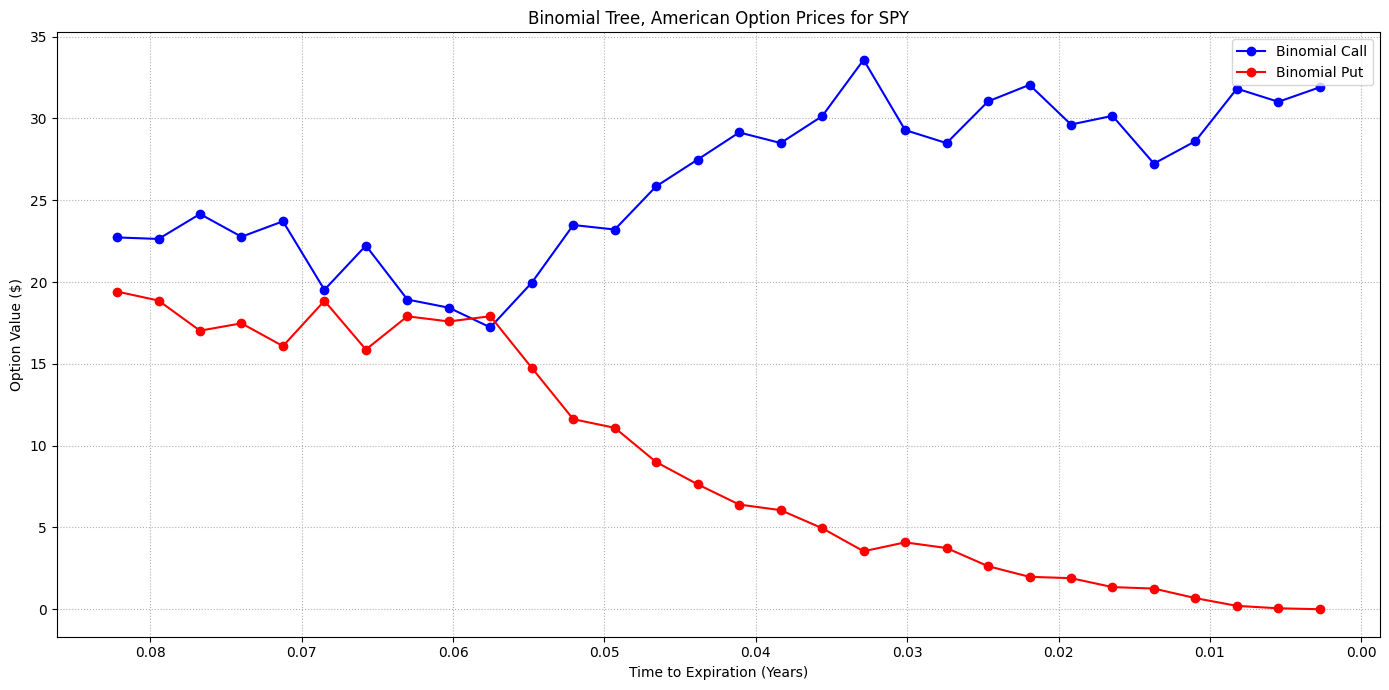

In [9]:
def binomial_american(S, K, T, r, sigma, N, option_type='call'):
    dt = T/N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt) - d)/(u - d)
    df = np.exp(-r*dt)

    # Stock price tree calculation
    stock_tree = np.zeros(N+1)
    for i in range(N+1):
        stock_tree[i] = S * (u**(N-i)) * (d**i)

    # Option value at expiration
    if option_type == 'call':
        option_tree = np.maximum(stock_tree - K, 0)
    else:  # put
        option_tree = np.maximum(K - stock_tree, 0)

    # Backward induction with early exercise check (for American Options)
    for n in range(N-1, -1, -1):

        stock_prices = S * (u**(np.arange(n+1, 0, -1) - np.arange(n+1)))[:n+1]
        continuation_value = (p * option_tree[:-1] + (1-p) * option_tree[1:]) * df

        #Options - Call
        if option_type == 'call':
            intrinsic_value = np.maximum(stock_prices - K, 0)
        #Options - Put
        else:
            intrinsic_value = np.maximum(K - stock_prices, 0)

        option_tree = np.maximum(continuation_value, intrinsic_value)

    return option_tree[0]


def analyze_stocks(stockList, days=30, r=0.0425, sigma=0.30, N_steps=500):
  plt.figure(figsize=(14,7))

  #Define all values
  all_call_values = []
  all_put_values = []
  all_T_values = []

  #Check if closing prices matches number of days
  for symbol in stockList:
    stock = yf.Ticker(symbol)
    hist = stock.history(period=f'{days+5}d')
    closing_prices = list(hist['Close'][-days:])

    if len(closing_prices) < days:
      print(f"[Warning] Not enough data for {symbol}. Skipping.")
      continue

    strike = closing_prices[0]
    call_values = []
    put_values = []
    T_values = []

    for i, price in enumerate(closing_prices):
      T = T_total - (i/365)
      if T <= 0:
        continue
      call_val = binomial_american(price, strike, T, r, sigma, N_steps, 'call')
      put_val = binomial_american(price, strike, T, r, sigma, N_steps, 'put')

      call_values.append(call_val)
      put_values.append(put_val)
      T_values.append(T)
    
    all_call_values.extend(call_values)
    all_put_values.extend(put_values)
    all_T_values.extend(T_values)


  #Plotting
  plt.plot(all_T_values, all_call_values, marker='o', color='blue', label='Binomial Call', linestyle = '-')
  plt.plot(all_T_values, all_put_values, marker='o', color='red', label='Binomial Put')

  plt.gca().invert_xaxis()
  plt.title('Binomial Tree, American Option Prices for SPY')
  plt.xlabel('Time to Expiration (Years)')
  plt.ylabel('Option Value ($)')
  plt.grid(True, linestyle=':')
  plt.legend(fontsize=10)
  plt.tight_layout()
  plt.show()

# Test parameters
r = 0.0425
sigma = 0.30
days = 30
T_total = days / 365
stockList = ['SPY']
N_steps = 10000  # Binomial steps

analyze_stocks(stockList)

# **Numerical Method #2: Crank-Nicholson PDE for Finite Differences**

Another way we could calculate European option prices was through the use of the Crank-Nicholson Finite Difference Method. The Crank-Nicholson Finite Difference Method is well suited to solve parabolic PDE, such as the heat equation in physics, and can be applied to solve the Black-Scholes PDE.

The model involves breaking time and price movement into small discrete points on a grid, which allows the Black-Scholes PDE to be approximated by a system of algebraic equations. This grid allows for a tridiagonal matrix to be used to iteratively solve each discrete step for the Black-Scholes PDE, moving backward from the option's price at maturity to the present option price for the current stock price.



In [5]:
# Crank-Nicholson Finite Difference Method (European)

def crank_nicolson(S, K, T, r, sigma, M=100, N=100, option_type='call'):
    """
    Variables:
    S: initial stock price
    K: strike price
    T: time to maturity
    r: risk-free rate
    sigma: volatility
    M: number of price steps
    N: number of time steps
    option_type: 'call' or 'put'
    """
    dt = T / N
    dS = 2 * S / M  # grid spacing for stock price
    grid = np.zeros((M + 1, N + 1))
    S_values = np.linspace(0, 2 * S, M + 1)

    # Set terminal payoff at maturity
    if option_type == 'call':
        grid[:, -1] = np.maximum(S_values - K, 0)
    else:
        grid[:, -1] = np.maximum(K - S_values, 0)

    # Setup coefficients
    j = np.arange(M + 1)
    alpha = 0.25 * dt * (sigma ** 2 * j ** 2 - r * j)
    beta = -0.5 * dt * (sigma ** 2 * j ** 2 + r)
    gamma = 0.25 * dt * (sigma ** 2 * j ** 2 + r * j)

    A = np.diag(1 - beta) + np.diag(-alpha[1:], -1) + np.diag(-gamma[:-1], 1)
    B = np.diag(1 + beta) + np.diag(alpha[1:], -1) + np.diag(gamma[:-1], 1)

    # Step backward in time
    for n in reversed(range(N)):
        grid[:, n] = np.linalg.solve(A, B @ grid[:, n + 1])
        grid[0, n] = 0  # boundary at S = 0
        grid[-1, n] = 2 * S - K if option_type == 'call' else K  # boundary at high S

    # Interpolate price for current S
    idx = np.searchsorted(S_values, S)
    return grid[idx, 0]

# Parameters (these can be imported dynamically from yfinance or set manually)
S = 100        # current stock price
K = 101.5      # strike price
T = 2          # time to expiration (years)
r = 0.0425     # risk-free rate
sigma = 0.30   # implied volatility
N = 500        # steps for binomial tree

# Run binomial (American option)
american_call = binomial_american(S, K, T, r, sigma, N, 'call')
american_put = binomial_american(S, K, T, r, sigma, N, 'put')

print(f"American call price (binomial): {american_call:.2f}")
print(f"American put price (binomial): {american_put:.2f}")

# Run Crank-Nicolson (European option)
european_call = crank_nicolson(S, K, T, r, sigma, M=100, N=100, option_type='call')
european_put = crank_nicolson(S, K, T, r, sigma, M=100, N=100, option_type='put')

print(f"European call price (Crank-Nicolson): {european_call:.2f}")
print(f"European put price (Crank-Nicolson): {european_put:.2f}")


American call price (binomial): 21.07
American put price (binomial): 13.61
European call price (Crank-Nicolson): 12.09
European put price (Crank-Nicolson): 14.70


Pricing American Options with Crank-Nicolson and Penalty in Log Space

Current SPY Price (S0): 629.15
Strike Price (K): 579


C:\Users\thapa\AppData\Local\Temp\ipykernel_12708\3815864741.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S0 = yf.Ticker(ticker).history(period='5d')['Close'][-1]


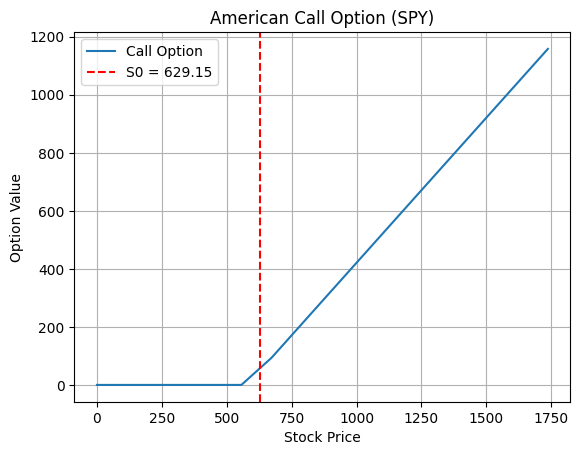

SPY American Call Option Value: 58.5971


In [6]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def cranknicolsonpenalty(S0, K, T, r, sigma, option_type='call', plot=False):
    M, N = 100, 100
    x = np.linspace(np.log(1e-5), np.log(3 * K), M + 1)
    S = np.exp(x)
    dt = T / N

    payoff = np.maximum(S - K, 0) if option_type == 'call' else np.maximum(K - S, 0)
    V = payoff.copy()

    i = np.arange(M + 1)
    alpha = 0.25 * dt * (sigma**2 * i**2 - r * i)
    beta  = -0.5 * dt * (sigma**2 * i**2 + r)
    gamma = 0.25 * dt * (sigma**2 * i**2 + r * i)

    A = np.eye(M + 1)
    for j in range(1, M):
        A[j, j-1] = -alpha[j]
        A[j, j]   = 1 - beta[j]
        A[j, j+1] = -gamma[j]
    B = A.T

    penalty = 1e6
    for _ in range(N):
        b = B @ V
        b[0] = b[-1] = 0
        for _ in range(10):
            V = np.linalg.solve(A + penalty * np.eye(M + 1), b + penalty * payoff)
            V = np.maximum(V, payoff)

    if plot:
        plt.plot(S, V, label=f'{option_type.capitalize()} Option')
        plt.axvline(S0, linestyle='--', color='red', label=f'S0 = {S0:.2f}')
        plt.xlabel('Stock Price')
        plt.ylabel('Option Value')
        plt.title(f'American {option_type.capitalize()} Option (SPY)')
        plt.legend()
        plt.grid(True)
        plt.show()

    return float(interp1d(S, V)(S0))


ticker = 'SPY'
S0 = yf.Ticker(ticker).history(period='5d')['Close'][-1]
r, T, K = 0.0425, 0.0027 , round(S0) - 50
sigma = 0.30

print(f"Current {ticker} Price (S0): {S0:.2f}")
print(f"Strike Price (K): {K}")

option_value = cranknicolsonpenalty(S0, K, T, r, sigma, option_type='call', plot=True)
print(f"{ticker} American Call Option Value: {option_value:.4f}")

# **Comparison of Numerical Methods to Black-Scholes Equation**

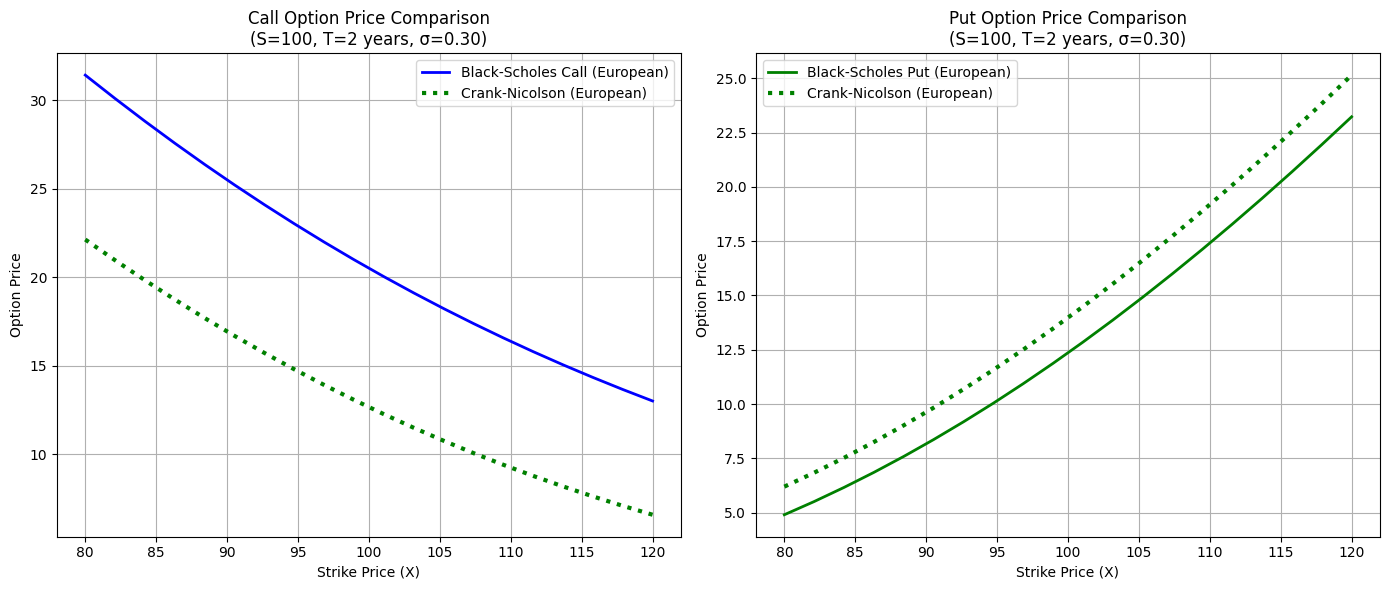

In [7]:
# 2. Parameters (using similar values from your file)
S = 100  # Stock price
X_range = np.linspace(80, 120, 20)  # Strike prices
T = 2.0  # Time to expiration (years)
r = 0.0425  # Risk-free rate
sigma = 0.30  # Volatility
binomial_steps = 500  # Binomial steps
fdm_steps = 100 #Steps for Crank-Nicolson

N = norm.cdf

def BlackSchole_Call(S, X, T, r, sigma):
    d1 = (np.log(S/X) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - X*np.exp(-r*T)*norm.cdf(d2)

def BlackSchole_Put(S, X, T, r, sigma):
    d1 = (np.log(S/X) + (r + (pow(sigma, 2) / 2)) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    return X*np.exp(-r*T)*N(-d2) - S*N(-d1)


# 3. Calculate prices using methods for European Options
bs_call = [BlackSchole_Call(S, X, T, r, sigma) for X in X_range]
bs_put = [BlackSchole_Put(S, X, T, r, sigma) for X in X_range]

cn_call = [crank_nicolson(S, X, T, r, sigma, fdm_steps, fdm_steps, 'call') for X in X_range]
cn_put = [crank_nicolson(S, X, T, r, sigma, fdm_steps, fdm_steps, 'put') for X in X_range]

# 4. Create the comparison plot
plt.figure(figsize=(14, 6))

# Call options plot
plt.subplot(1, 2, 1)
plt.plot(X_range, bs_call, 'b-', label='Black-Scholes Call (European)', linewidth=2)
plt.plot(X_range, cn_call, 'g:', label='Crank-Nicolson (European)', linewidth=3)
plt.title('Call Option Price Comparison\n(S=100, T=2 years, σ=0.30)')
plt.xlabel('Strike Price (X)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)

# Put options plot
plt.subplot(1, 2, 2)
plt.plot(X_range, bs_put, 'g-', label='Black-Scholes Put (European)', linewidth=2)
plt.plot(X_range, cn_put, 'g:', label='Crank-Nicolson (European)', linewidth=3)
plt.title('Put Option Price Comparison\n(S=100, T=2 years, σ=0.30)')
plt.xlabel('Strike Price (X)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

ValueError: A value (1737.0) in x_new is above the interpolation range's maximum value (1736.9999999999995).

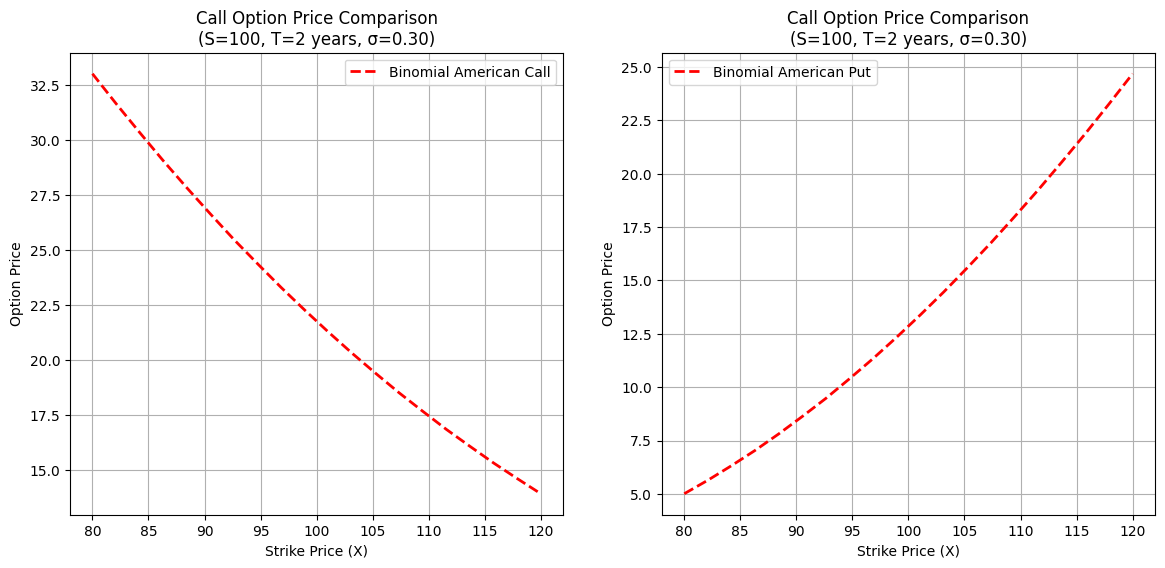

In [8]:
am_call = [binomial_american(S, X, T, r, sigma, binomial_steps, 'call') for X in X_range]
am_put = [binomial_american(S, X, T, r, sigma, binomial_steps, 'put') for X in X_range]

# 4. Create the comparison plot
plt.figure(figsize=(14, 6))

# Call options plot
plt.subplot(1, 2, 1)
plt.plot(X_range, am_call, 'r--', label='Binomial American Call', linewidth=2)
plt.title('Call Option Price Comparison\n(S=100, T=2 years, σ=0.30)')
plt.xlabel('Strike Price (X)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)

# Put options plot
plt.subplot(1, 2, 2)
plt.plot(X_range, am_put, 'r--', label='Binomial American Put', linewidth=2)
plt.title('Call Option Price Comparison\n(S=100, T=2 years, σ=0.30)')
plt.xlabel('Strike Price (X)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)

# Call option
call_value = cranknicolsonpenalty(S0, K, T, r, sigma, option_type='call', plot=False)
S_values = np.linspace(1, 3*K, 200)
call_values = [cranknicolsonpenalty(s, K, T, r, sigma, option_type='call') for s in S_values]
plt.plot(S_values, call_values, 'b-', label='Call Option')

# Put option
put_value = cranknicolsonpenalty(S0, K, T, r, sigma, option_type='put', plot=False)
put_values = [cranknicolsonpenalty(s, K, T, r, sigma, option_type='put') for s in S_values]
plt.plot(S_values, put_values, 'r-', label='Put Option')

# Add details to plot
plt.axvline(S0, linestyle='--', color='green', label=f'Current Price = {S0:.2f}')
plt.axvline(K, linestyle=':', color='black', label=f'Strike Price = {K}')
plt.xlabel('Stock Price')
plt.ylabel('Option Value')
plt.title(f'SPY American Options\n(K={K}, T={T:.4f} years, r={r:.2%}, σ={sigma:.2%})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n{ticker} American Call Option Value: {call_value:.4f}")
print(f"{ticker} American Put Option Value: {put_value:.4f}")

References:

[Binomial Pricing Models](https://www.kent.ac.uk/learning/documents/slas-documents/Binomial_models.pdf)

